In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-price-prediction-dataset/House Price Prediction Dataset.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"/kaggle/input/house-price-prediction-dataset/House Price Prediction Dataset.csv")

In [4]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [5]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
df.shape

(2000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [8]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


Text(0.5, 1.0, 'Distribution of Area')

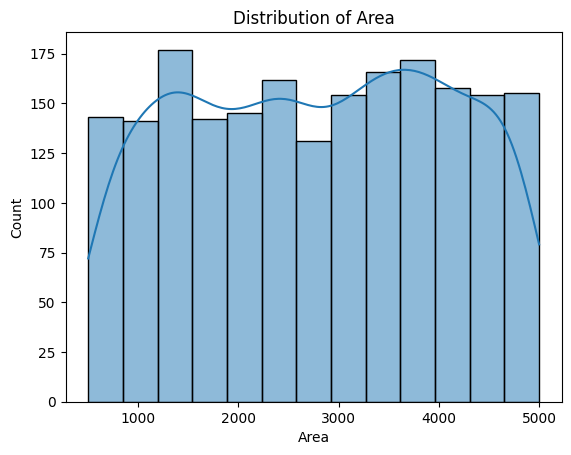

In [11]:
sns.histplot(df['Area'], kde=True)
plt.title("Distribution of Area")

Text(0.5, 1.0, 'Boxplot of House Price')

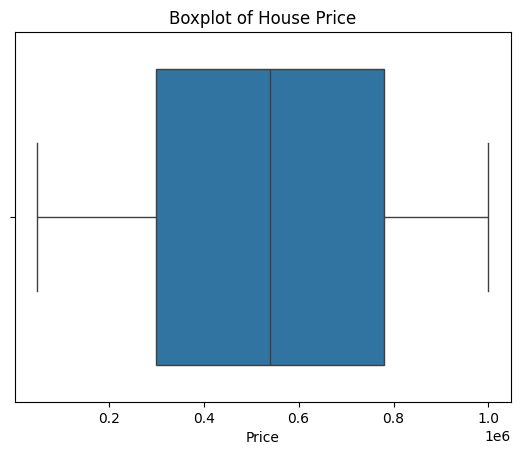

In [12]:
sns.boxplot(x=df['Price'])
plt.title("Boxplot of House Price")

Text(0, 0.5, 'Price')

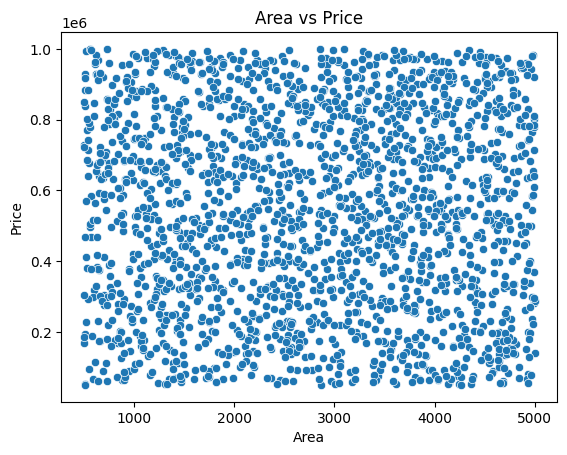

In [13]:
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
X = df[['Area', 'Bedrooms', 'Bathrooms']]   # Features
y = df['Price']                             # Target

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train.shape

(1600, 3)

In [29]:
X_test.shape

(400, 3)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred

array([522171.74062846, 551143.21917408, 522026.6322543 , 551321.92605739,
       541453.78898837, 551150.95691147, 521974.14982511, 521920.14801541,
       541529.06712945, 541346.15983479, 541427.92821661, 551183.77540854,
       531590.03358659, 531705.76538017, 521863.38171934, 551282.61253798,
       551019.67096917, 531635.83256513, 531825.98142297, 541623.80403872,
       541436.89193343, 522039.70336371, 521790.20737013, 551033.40994549,
       531786.95413223, 531502.63365006, 541598.61352466, 531739.62860077,
       531842.48010406, 522025.38475764, 521772.26559166, 522080.91312026,
       551411.6086509 , 541500.62790883, 541442.43286019, 521797.74233439,
       541576.19227859, 550985.32591917, 521819.30250364, 541405.98879992,
       521856.12820214, 551275.84563179, 551209.34038842, 531604.62646732,
       541582.20068992, 521865.19450093, 531798.01925013, 541392.34523316,
       521763.68112227, 531518.66484657, 521783.14228125, 531606.63484964,
       541360.28044934, 5

In [33]:
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

In [36]:
print("\nPredicted vs Actual Values (First 10):")
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}) 
print(comparison.head(10))



Predicted vs Actual Values (First 10):
   Actual      Predicted
0  514764  522171.740628
1  694256  551143.219174
2   66375  522026.632254
3  650243  551321.926057
4  223285  541453.788988
5  468127  551150.956911
6  513002  521974.149825
7  911525  521920.148015
8  723265  541529.067129
9  339416  541346.159835


In [37]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [39]:
print("\nModel Evaluation Metrics:") 
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


Model Evaluation Metrics:
MSE  : 78440549944.81049
RMSE : 280072.40125512274
R2 Score : -0.008248471565956539


In [40]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

-0.015886717562668462

In [42]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

In [54]:
print("\nOverfitting / Underfitting Check:")

if train_score > 0.7 and test_score < 0.5:
    print("Overfitting Detected")

elif train_score < 0.3 and test_score < 0.3:
    print("Underfitting Detected")

else:
    print("Model is reasonably balanced")



Overfitting / Underfitting Check:
Underfitting Detected


In [46]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})


In [47]:
print("\nFeature Importance (Linear Coefficients):")
print(coefficients)


Feature Importance (Linear Coefficients):
     Feature  Coefficient
0       Area    -0.095410
1   Bedrooms   -13.259538
2  Bathrooms -9759.661183


In [49]:
print("\nIntercept:", model.intercept_)


Intercept: 561284.0391500255


In [52]:
print(df[['Area','Bedrooms','Bathrooms','Price']].corr())

               Area  Bedrooms  Bathrooms     Price
Area       1.000000  0.047523   0.021881  0.001542
Bedrooms   0.047523  1.000000  -0.011990 -0.003471
Bathrooms  0.021881 -0.011990   1.000000 -0.015737
Price      0.001542 -0.003471  -0.015737  1.000000


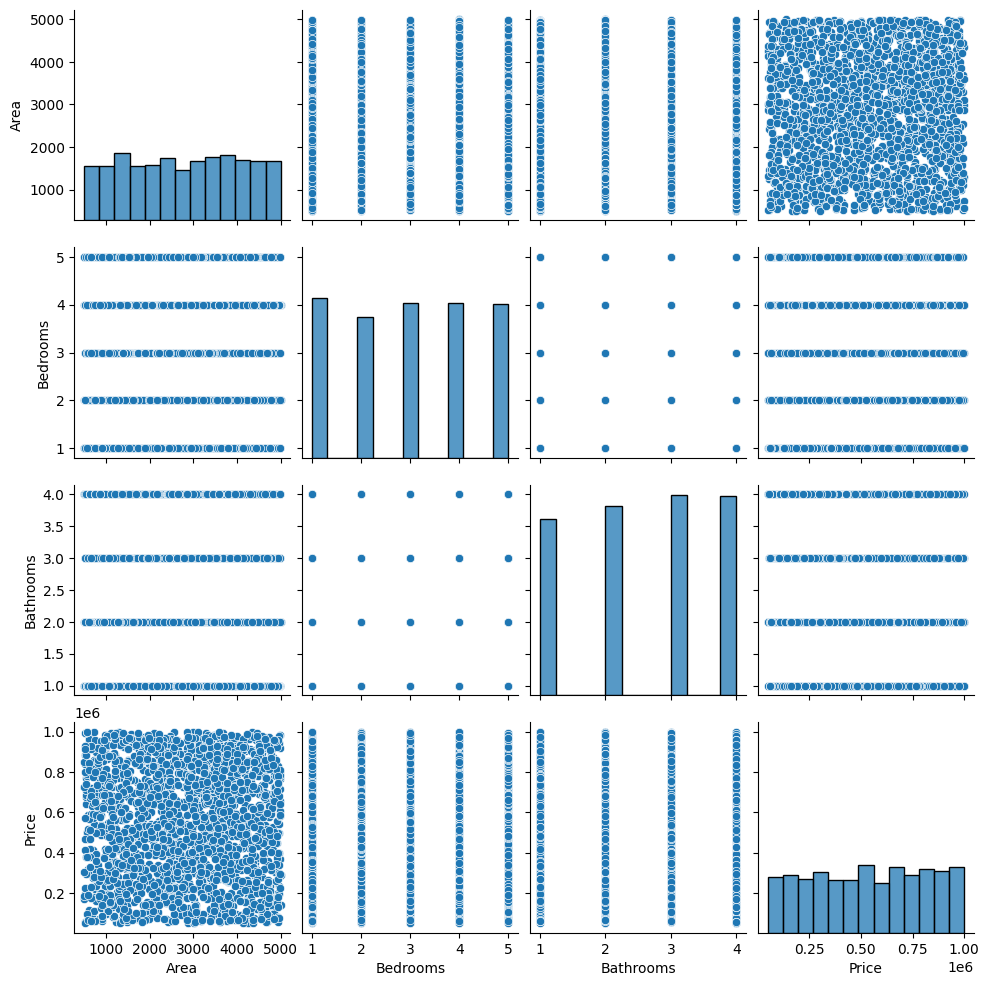

In [53]:
sns.pairplot(df[['Area','Bedrooms','Bathrooms','Price']])

In [55]:
X = df[['Area', 'Bedrooms', 'Bathrooms']]

In [56]:
df = pd.get_dummies(df, drop_first=True)

In [57]:
print(df.corr()['Price'].sort_values(ascending=False))

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64


In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [61]:
from sklearn.preprocessing import PolynomialFeatures

In [62]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [64]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [65]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.814640221211637
Test R2: -0.4439776685545844


In [66]:
df = df[df['Price'] < df['Price'].quantile(0.99)]

In [67]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price',
       'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes'],
      dtype='object')

In [68]:
X = df.drop(['Id', 'Price'], axis=1)
y = df['Price']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [70]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [71]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)


In [72]:
train_score

0.005510302539027734

In [73]:
test_score

0.012105617519646339

In [74]:
y_pred = model.predict(X_test)

In [75]:
y_pred

array([522132.60648734, 576140.63752436, 555576.97065773, 523127.47618274,
       514926.09124578, 524067.46257803, 525825.85493439, 546667.36333592,
       536007.94427629, 506227.98378542, 530673.12831513, 567066.64201388,
       555479.63020906, 508041.80769082, 583923.75426425, 518206.60292098,
       511216.71842632, 522501.20836261, 530194.5274806 , 548944.70955358,
       557983.00414993, 516189.24220607, 556041.3254568 , 524484.58022594,
       534965.98326421, 543468.68843889, 517473.23688156, 550376.11245433,
       529849.01275412, 530546.52472812, 527747.2067702 , 545792.68857927,
       527091.33795932, 535687.91755697, 538218.68713123, 539786.04387806,
       488496.16563054, 542594.05946935, 540713.91635109, 536589.3494924 ,
       521060.17639602, 508512.72348123, 552576.06124184, 540023.61953913,
       531419.9045298 , 548829.71455735, 524072.94365744, 550301.05043666,
       546027.66058706, 574571.41996426, 553571.70533177, 537646.29357324,
       509398.09923552, 4

In [76]:
r2 = r2_score(y_test, y_pred)
r2

0.012105617519646339

In [77]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

-0.01884668689227076

In [79]:
mean_squared_error(y_test, y_pred)

73748409336.69368

In [82]:
rmse = np.sqrt(mse)
rmse = float (rmse)
rmse

280072.40125512274

In [83]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print("RF Train R2:", rf.score(X_train, y_train))
print("RF Test R2 :", rf.score(X_test, y_test))

RF Train R2: 0.8455264321137778
RF Test R2 : -0.03918513943396329


In [85]:
rf_train = rf.score(X_train, y_train)
rf_test = rf.score(X_test, y_test)

print("\nOverfitting / Underfitting Check:")

if rf_train - rf_test > 0.2:
    print("Overfitting Detected")

elif rf_train < 0.3 and rf_test < 0.3:
    print("Underfitting Detected")

else:
    print("Model is reasonably balanced")



Overfitting / Underfitting Check:
Overfitting Detected


In [ ]:
#In this model predicts: House Price

#It uses features like: Area, Bedrooms, Bathrooms, Floors, YearBuilt,
#Location, Condition, Garage

#It learns the relationship between these inputs and the house price, 
#then predicts the price for new houses.

In [ ]:
#MSE (Mean Squared Error)
#Average squared difference between actual and predicted price.
#Lower = better
#Large value = big prediction errors


#RMSE (Root Mean Squared Error)
#Square root of MSE.
#Same unit as price
#Tells how much prediction is off on average

#Example:
#RMSE = 50,000
#→ Model is wrong by about 50,000 on average.


#R² Score
#How much variance in price the model explains.
#Range:
#1 → Perfect
#0 → Useless
#Negative → Worse than predicting average

In [ ]:
#Compare: Train R² and Test R²
#Overfitting
#Train score = High
#Test score = Low
#→ Model memorized training data
#→ Poor performance on new data

#Underfitting
#Train score = Low
#Test score = Low
#→ Model too simple
#→ Cannot learn pattern

#Good Model
#Train score ≈ Test score
#Both reasonably high
#→ Model generalizes well